# Imports and Paths

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import hdf5plugin  # to read the compressed data
import os
import gc
import sys
import torch
from torch.utils.data import DataLoader, Subset, Dataset as TorchDataset
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import stable_worldmodel as swm  # to load and run LeWM
from stable_worldmodel.data.formats.hdf5 import HDF5Dataset
import stable_pretraining as spt

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constants

# Paths and Helper Imports

In [2]:
here = Path.cwd().resolve()
REPO_ROOT = next(
    p for p in [here, *here.parents]
    if (p / "scripts" / "download_data.py").is_file()
)
print("REPO_ROOT", REPO_ROOT)

LEWM_DIR = REPO_ROOT / "third_party" / "le-wm"
if str(LEWM_DIR) not in sys.path:
    sys.path.insert(0, str(LEWM_DIR))

from utils import get_column_normalizer, get_img_preprocessor

H5_PATH = REPO_ROOT / "data" / "processed" / "pusht_expert_train.h5"
os.environ["STABLEWM_HOME"] = str(REPO_ROOT / "data" / "stablewm")  # assign, not setdefault

device = "cuda" if torch.cuda.is_available() else "cpu"
model = swm.policy.AutoCostModel("pusht/lewm").to(device).eval()

REPO_ROOT /workspace/Safety-Dial
20:05:21 | INFO  | __init__.py | JAX version 0.10.2 available.
20:05:24 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)


# Helper Funcs

In [3]:
# We use the same normalisation that they use in their pipeline during training
prep = get_img_preprocessor(source="pixels", target="pixels", img_size=224)

def pixels_to_tensor(frames_hwc):
    model_device = next(model.parameters()).device
    xs = []
    for f in frames_hwc:
        sample = {"pixels": f}
        prep(sample)
        xs.append(sample["pixels"])
    return torch.stack(xs, 0).unsqueeze(0).to(model_device)

#It get's super annoying when you open an already opened hd5 so
def closeh5():
    g = globals()
    f = g.get("file")
    if f is not None:
        f.close()

#To convert from that clip to the global row in the hdf5
def clip_to_global_row(dataset, clip_idx):
    ep, start = dataset.clip_indices[clip_idx]
    return int(dataset.offsets[ep] + start)

# Prepping the data

In [4]:
#So initially did some random sampling but coz hdf5 is uncompressed and indexes scattered, takes long
# dataset = HDF5Dataset(
#     path=str(H5_PATH),
#     num_steps=1, #One frame per sample
#     frameskip=1, #Basically the temporal stride
#     keys_to_load=["pixels", "state"], #We only need these to train the probe
#     keys_to_cache=["state"], #This loads into RAM, pixels too big
#     transform=prep)

# MAX_SAMPLES = 50_000 #Theres something like 2.3m 50k should suffice
# #We sort because hdf5 reads faster when sequential
# rng = np.random.default_rng(0)
# idx = rng.choice(len(dataset), size=min(MAX_SAMPLES, len(dataset)), replace=False)
# idx.sort()

In [5]:
closeh5()

# # We simply use the first 50_000 samples
# MAX_SAMPLES = 50_000
# rng = np.random.default_rng(0)

# # Sequential read, much faster than random fancy indexing
# with h5py.File(H5_PATH, "r") as f:
#     pixels_cache = f["pixels"][:MAX_SAMPLES]       # (50000, 224, 224, 3) uint8
#     # coords_cache = f["state"][:MAX_SAMPLES, 2:4]   # (50000, 2) block_x, block_y #This is for block
#     coords_cache = f["state"][:MAX_SAMPLES, 0:2]  # pusher_x, pusher_y

MAX_SAMPLES = 50_000
N_CHUNKS = 100
CHUNK_SIZE = MAX_SAMPLES // N_CHUNKS
rng = np.random.default_rng(0)

with h5py.File(H5_PATH, "r") as f:
    total = len(f["pixels"])
    starts = np.linspace(
        0,
        total - CHUNK_SIZE,
        N_CHUNKS,
        dtype=int,
    )

    pixels_cache = np.concatenate([
        f["pixels"][s:s + CHUNK_SIZE]
        for s in starts
    ])

    coords_cache = np.concatenate([
        f["state"][s:s + CHUNK_SIZE, :2]
        for s in starts
    ])

print(f"{pixels_cache.nbytes / 1e9:.2f} GB pixels loaded")
print(pixels_cache.shape, coords_cache.shape)

# Random train/test split in RAM
perm = rng.permutation(MAX_SAMPLES)
n_train = int(0.8 * MAX_SAMPLES)
train_rel = perm[:n_train]
test_rel = perm[n_train:]

7.53 GB pixels loaded
(50000, 224, 224, 3) (50000, 2)


# Creating the Dataloaders

In [6]:
class CachedPushTSamples(TorchDataset):
    def __init__(self, pixels_u8, coords, transform):
        self.pixels = pixels_u8
        self.coords = coords
        self.transform = transform

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, i):
        # match HDF5Dataset: (1, H, W, C) -> (1, C, H, W), then prep (LeWM expects channels first)
        x = torch.from_numpy(self.pixels[i:i+1]).permute(0, 3, 1, 2)
        sample = {"pixels": x, "state": torch.from_numpy(self.coords[i:i+1])}
        return self.transform(sample) if self.transform else sample

cached = CachedPushTSamples(pixels_cache, coords_cache, prep)

loader_kwargs = dict(batch_size=512, num_workers=0, pin_memory=True, shuffle=False)
train_loader = DataLoader(Subset(cached, train_rel.tolist()), **loader_kwargs)
test_loader  = DataLoader(Subset(cached, test_rel.tolist()),  **loader_kwargs)

batch = next(iter(train_loader))
print(batch["pixels"].shape, batch["state"].shape)

torch.Size([512, 1, 3, 224, 224]) torch.Size([512, 1, 2])


# Encoding the frames

In [7]:
@torch.inference_mode()
def encode_loader(loader, desc="encode"):
    zs, ys = [], []
    for batch in tqdm(loader, desc=desc, total=len(loader)):
        pixels = batch["pixels"].to(device, non_blocking=True)
        y = batch["state"][:, 0].float().numpy()          # (B, 2) block xy
        z = model.encode({"pixels": pixels})["emb"][:, 0].cpu().numpy()  # (B, 192)
        zs.append(z)
        ys.append(y)
    return np.concatenate(zs), np.concatenate(ys)

Z_train, Y_train = encode_loader(train_loader, desc="train")
Z_test, Y_test = encode_loader(test_loader, desc="test")
print(Z_train.shape, Y_train.shape, Z_test.shape, Y_test.shape)

test: 100%|██████████| 20/20 [00:25<00:00,  1.26s/it]

(40000, 192) (40000, 2) (10000, 192) (10000, 2)


In [8]:
# Now we can free the pixel mem
del pixels_cache, cached, train_loader, test_loader
gc.collect()
if device == "cuda":
    del model
    torch.cuda.empty_cache()

# Training Ridge Regression model

Linear probe: LeWM latents → block (x, y)
  samples : 10,000 test / 40,000 train
  alpha   : 1.0
  R²      : 0.9639  (x: 0.9677, y: 0.9601)
  RMSE    : 19.29 px  (x: 18.34, y: 20.19)


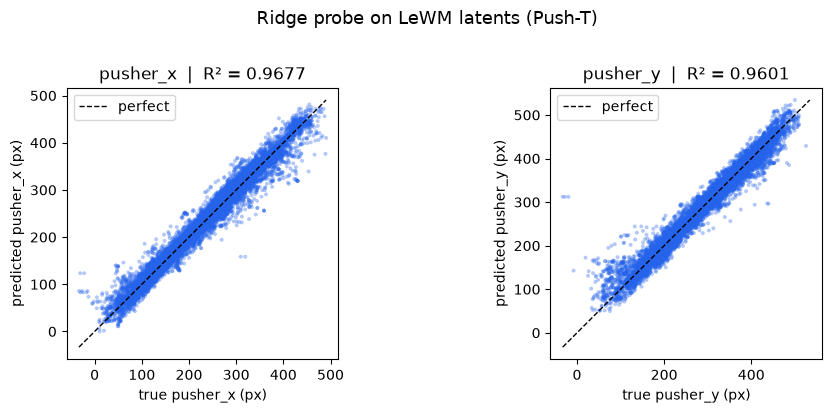

In [9]:
pusher_probe = Ridge(alpha=1.0).fit(Z_train, Y_train)

Y_pred = pusher_probe.predict(Z_test)

r2 = r2_score(Y_test, Y_pred) #How well do the predicted block coords match the real
r2_x = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_y = r2_score(Y_test[:, 1], Y_pred[:, 1])
rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))
rmse_x = np.sqrt(np.mean((Y_test[:, 0] - Y_pred[:, 0]) ** 2))
rmse_y = np.sqrt(np.mean((Y_test[:, 1] - Y_pred[:, 1]) ** 2))

print("Linear probe: LeWM latents → block (x, y)")
print(f"  samples : {len(Y_test):,} test / {len(Y_train):,} train")
print(f"  alpha   : {pusher_probe.alpha}")
print(f"  R²      : {r2:.4f}  (x: {r2_x:.4f}, y: {r2_y:.4f})")
print(f"  RMSE    : {rmse:.2f} px  (x: {rmse_x:.2f}, y: {rmse_y:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, dim, name, r2_dim in zip(
    axes, [0, 1], ["pusher_x", "pusher_y"], [r2_x, r2_y]
):
    ax.scatter(Y_test[:, dim], Y_pred[:, dim], s=8, alpha=0.35, c="#2563eb", edgecolors="none")
    lo = min(Y_test[:, dim].min(), Y_pred[:, dim].min())
    hi = max(Y_test[:, dim].max(), Y_pred[:, dim].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    ax.set_xlabel(f"true {name} (px)")
    ax.set_ylabel(f"predicted {name} (px)")
    ax.set_title(f"{name}  |  R² = {r2_dim:.4f}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

fig.suptitle("Ridge probe on LeWM latents (Push-T)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Testing the Avoidance

## Imports

In [32]:
import gymnasium as gym
from sklearn import preprocessing
from stable_worldmodel.solver import CEMSolver
from IPython.display import display
import importlib
import helpers.linProbeHelpers as lph

importlib.reload(lph)
from helpers.linProbeHelpers import *

## Helpers

In [33]:
pixel_prep = get_img_preprocessor("pixels", "pixels", img_size=224)
goal_prep  = get_img_preprocessor("goal", "goal", img_size=224)

transform = {
    "pixels": wm_transform(pixel_prep, "pixels"),
    "goal":   wm_transform(goal_prep, "goal"),
}

## Creating the custom test state

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


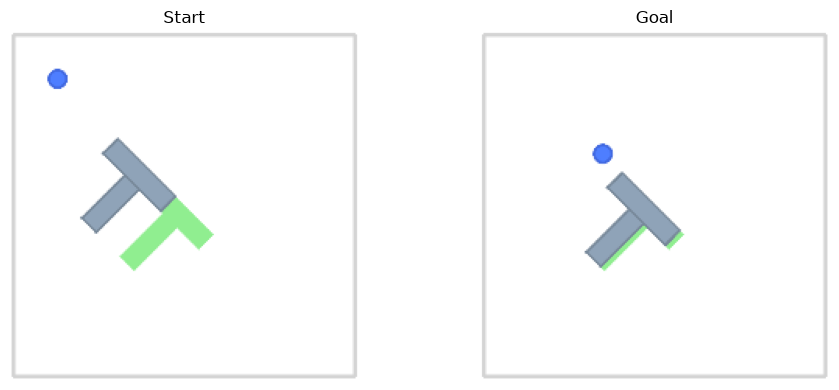

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [34]:
start_state = make_pusht_state(
    pusher_xy=(70, 70),    # just above/right of block — tune visually
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)

goal_state = make_pusht_state(
    pusher_xy=(180, 180),    # near goal block too (success checks both)
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(start_state, goal_state)

In [35]:
# Unfortunatley LeWM doesn't take in the raw env data so we need to build out the normalisation dict
dataset = swm.data.HDF5Dataset(
    path=str(H5_PATH),  
    keys_to_cache=["action", "proprio", "state"],
)
process = {}
for col in ["action", "proprio", "state"]:
    proc = preprocessing.StandardScaler()
    data = dataset.get_col_data(col)
    data = data[~np.isnan(data).any(axis=1)]
    proc.fit(data)
    process[col] = proc
    if col != "action":
        process[f"goal_{col}"] = proc

20:20:19 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
20:20:19 | INFO  | __init__.py | Cached 'proprio' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
20:20:20 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


## Loading in the Model and Planner

In [36]:
#We init the same params as LeWM
model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
plan_config = swm.PlanConfig(
    horizon=5, #Plans 5 decision steps/latent actions
    receding_horizon=5, #Executing all 5 before re planning
    action_block=5)

solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.8999 seconds
CEM solve time: 0.9007 seconds
success: True
final state: [ 182.8639979   193.69891938  255.23630479  247.99006861    0.71241992
   -0.57963359 -103.9830246 ]
goal state:  [180.         180.         250.         250.           0.78539816
   0.           0.        ]
steps: 50
20:20:24 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


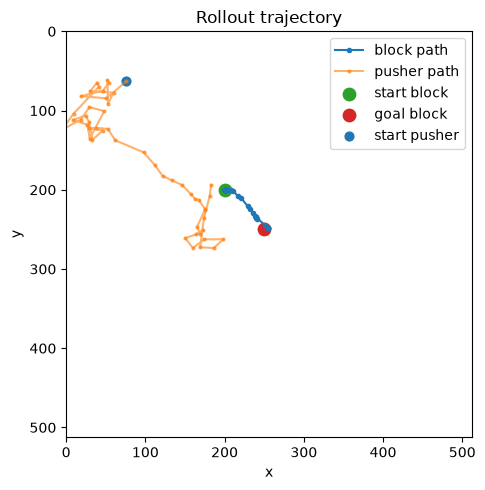

In [37]:
# --- world + custom reset ---
EVAL_BUDGET = 50  # same as le-wm pusht eval
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []

world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)
states = np.stack(states)  # (T, 7)
success = bool(world.terminateds[0])
print("success:", success)
print("final state:", states[-1])
print("goal state: ", goal_state)
print("steps:", len(frames))

display(animate_frames(frames, interval_ms=100))
plot_trajectory(states, start_state, goal_state)

## Testing it out with the Hazard

## Setting up the Hazard env

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


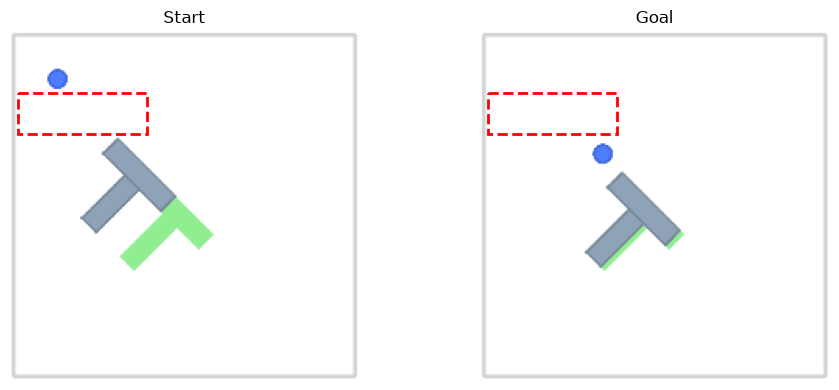

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [45]:
# Corridor box between start block (200,200) and goal (250,250)
hazard_box = (10.0, 200.0, 90.0, 150.0)  # (x_min, x_max, y_min, y_max) near top-left

start_state = make_pusht_state(
    pusher_xy=(70, 70),
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)
goal_state = make_pusht_state(
    pusher_xy=(180, 180),
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(start_state, goal_state, hazard_box=hazard_box)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9124 seconds
CEM solve time: 0.9895 seconds

CEM solve 1
  first: goal median=403.119, hazard max=8.100, hazard nonzero=0.037
  final: goal median=293.580, hazard max=0.000, hazard nonzero=0.000

CEM solve 2
  first: goal median=413.225, hazard max=1.183, hazard nonzero=0.003
  final: goal median=67.774, hazard max=12.006, hazard nonzero=0.157
Last CEM iteration cost scales
goal:   min=11.4987, median=67.7736, max=349.4521
hazard: min=0.0000, median=0.0000, max=12.0057
λ·hazard: min=0.0000, median=0.0000, max=1200.5707
nonzero hazard fraction: 0.15666666626930237
λ=100.0
success: False
violation: {'any_violation': True, 'n_violating_steps': 16, 'frac_violating': 0.32}
final block xy: [259.27696642 242.49181929]
goal block xy: [250. 250.]
21:20:57 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


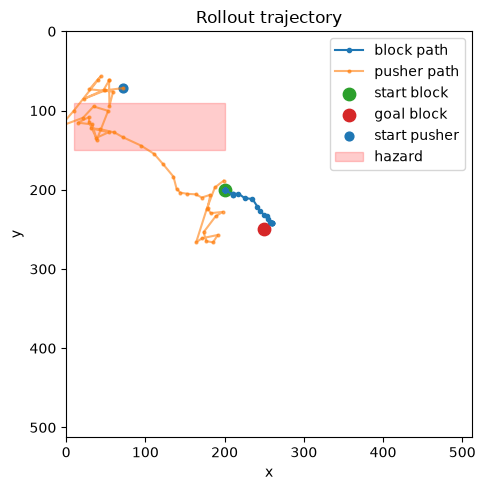

In [47]:
LAM = 100.0  # try 0 first (= baseline), then 1e-2, 1e-1, 1, 10, 100, ...

base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
model = HazardAugmentedCostModel(
    base_model, pusher_probe, hazard_box, lam=LAM
).to("cuda").eval()

plan_config = swm.PlanConfig(horizon=5, receding_horizon=5, action_block=5)
solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

EVAL_BUDGET = 50
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []
world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)

solve_diagnostics = summarize_cem_history(model)

goal_costs = model.last_goal_cost.float()
hazard_costs = model.last_hazard_cost.float()
weighted_hazard = LAM * hazard_costs

print("Last CEM iteration cost scales")
print(
    f"goal:   min={goal_costs.min():.4f}, "
    f"median={goal_costs.median():.4f}, "
    f"max={goal_costs.max():.4f}"
)
print(
    f"hazard: min={hazard_costs.min():.4f}, "
    f"median={hazard_costs.median():.4f}, "
    f"max={hazard_costs.max():.4f}"
)
print(
    f"λ·hazard: min={weighted_hazard.min():.4f}, "
    f"median={weighted_hazard.median():.4f}, "
    f"max={weighted_hazard.max():.4f}"
)
print(
    "nonzero hazard fraction:",
    (hazard_costs > 0).float().mean().item(),
)

states = np.stack(states)
success = bool(world.terminateds[0])
viol = real_violation_stats(states, hazard_box, entity="pusher")

print(f"λ={LAM}")
print("success:", success)
print("violation:", viol)
print("final block xy:", states[-1, 2:4])
print("goal block xy:", goal_state[2:4])

display(animate_frames(frames, interval_ms=100))
plot_trajectory(states, start_state, goal_state, hazard_box=hazard_box)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9133 seconds
CEM solve time: 0.9130 seconds
λ=0        success=True viol=0.28 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9148 seconds
CEM solve time: 0.9139 seconds
λ=0.01     success=False viol=0.32 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


...

CEM solve time: 0.9159 seconds
CEM solve time: 0.9136 seconds
λ=1        success=True viol=0.32 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9141 seconds
CEM solve time: 0.9146 seconds
λ=10       success=False viol=0.30 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9133 seconds
CEM solve time: 0.9150 seconds
λ=100      success=True viol=0.31 solve1 initial hazard max=5.36 solve1 final hazard max=0.00 final nonzero=0.00


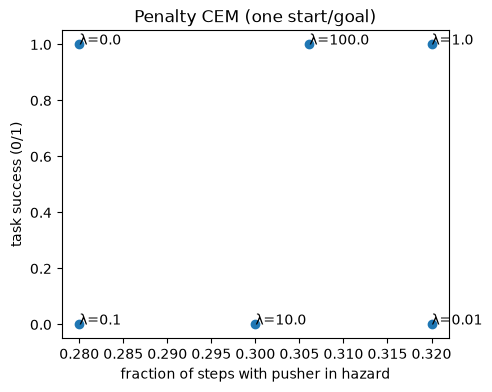

In [40]:
def run_hazard_episode(lam, seed=0):
    base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
    cost_model = HazardAugmentedCostModel(
        base_model, pusher_probe, hazard_box, lam=lam
    ).to("cuda").eval()

    solver = CEMSolver(
        model=cost_model,
        batch_size=1,
        num_samples=300,
        var_scale=1.0,
        n_steps=30,
        topk=30,
        device="cuda",
        seed=seed,
    )
    policy = swm.policy.WorldModelPolicy(
        solver=solver,
        config=swm.PlanConfig(horizon=5, receding_horizon=5, action_block=5),
        process=process,
        transform=transform,
    )
    world = swm.World(
        "swm/PushT-v1",
        num_envs=1,
        image_shape=(224, 224),
        max_episode_steps=100,
    )
    world.set_policy(policy)
    world.reset(seed=seed, options={"state": start_state, "goal_state": goal_state})

    frames, states = [], []
    world._run(max_steps=50, mode="wait", on_step=make_on_step(frames, states))
    solve_diagnostics = summarize_cem_history(
        cost_model,
        verbose=False,
    )
    goal_costs = cost_model.last_goal_cost.float()
    hazard_costs = cost_model.last_hazard_cost.float()
    weighted_hazard = lam * hazard_costs
    
    cost_diagnostics = {
        "goal_min": goal_costs.min().item(),
        "goal_median": goal_costs.median().item(),
        "goal_max": goal_costs.max().item(),
        "hazard_min": hazard_costs.min().item(),
        "hazard_median": hazard_costs.median().item(),
        "hazard_max": hazard_costs.max().item(),
        "weighted_hazard_median": weighted_hazard.median().item(),
        "nonzero_hazard_fraction": (
            (hazard_costs > 0).float().mean().item()
        ),
        "solve_diagnostics": solve_diagnostics,
    }
    
    states = np.stack(states)
    viol = real_violation_stats(states, hazard_box)
    return {
        "lam": lam,
        "success": bool(world.terminateds[0]),
        **viol,
        **cost_diagnostics,
        "states": states,
        "frames": frames,
    }


results = []
for lam in [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]:
    r = run_hazard_episode(lam)
    results.append(r)

    solve1 = r["solve_diagnostics"][0]

    print(
        f"λ={lam:<8g} "
        f"success={r['success']} "
        f"viol={r['frac_violating']:.2f} "
        f"solve1 initial hazard max={solve1['first_hazard_max']:.2f} "
        f"solve1 final hazard max={solve1['final_hazard_max']:.2f} "
        f"final nonzero={solve1['final_hazard_nonzero']:.2f}"
    )

# quick Pareto view
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    [r["frac_violating"] for r in results],
    [float(r["success"]) for r in results],
)
for r in results:
    ax.annotate(f"λ={r['lam']}", (r["frac_violating"], float(r["success"])))
ax.set_xlabel("fraction of steps with pusher in hazard")
ax.set_ylabel("task success (0/1)")
ax.set_title("Penalty CEM (one start/goal)")
plt.show()

In [44]:
# Export all sweep animations as labeled MP4 files
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, writers

animation_dir = (
    REPO_ROOT
    / "outputs"
    / "animations"
    / "linear_probe_avoidance"
)
animation_dir.mkdir(parents=True, exist_ok=True)

if not writers.is_available("ffmpeg"):
    raise RuntimeError(
        "Matplotlib cannot find ffmpeg. Install ffmpeg before exporting MP4."
    )


def save_frames_as_mp4(
    frames,
    output_path,
    label,
    *,
    fps=10,
    figsize=(5, 5),
):
    """Save a sequence of RGB frames as a labeled MP4."""
    if not frames:
        raise ValueError(f"No frames available for {label}")

    video_frames = [np.asarray(frame) for frame in frames]

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    image = ax.imshow(video_frames[0])
    title = ax.set_title(f"{label}\nstep 1/{len(video_frames)}")

    def update(frame_idx):
        image.set_data(video_frames[frame_idx])
        title.set_text(
            f"{label}\nstep {frame_idx + 1}/{len(video_frames)}"
        )
        return image, title

    animation = FuncAnimation(
        fig,
        update,
        frames=len(video_frames),
        interval=1000 / fps,
        blit=False,
    )

    writer = FFMpegWriter(
        fps=fps,
        metadata={
            "title": label,
            "artist": "Safety-Dial",
            "comment": "Push-T LeWM hazard-avoidance experiment",
        },
        bitrate=1800,
        extra_args=["-pix_fmt", "yuv420p"],
    )

    animation.save(
        str(output_path),
        writer=writer,
        dpi=100,
    )
    plt.close(fig)


manifest = []

# `results` contains every λ run, including λ=0 as the baseline.
for result in results:
    lam = result["lam"]
    success = bool(result["success"])
    violation = float(result["frac_violating"])
    frames = result["frames"]

    lambda_label = f"{lam:g}"
    filename_label = (
        lambda_label
        .replace(".", "p")
        .replace("-", "m")
    )

    filename = f"lambda_{filename_label}.mp4"
    output_path = animation_dir / filename

    video_label = (
        f"Penalty CEM | λ={lambda_label} | "
        f"success={success} | violation={violation:.2f}"
    )

    save_frames_as_mp4(
        frames,
        output_path,
        video_label,
        fps=10,
    )

    manifest.append({
        "label": video_label,
        "lambda": float(lam),
        "file": filename,
        "success": success,
        "fraction_violating": violation,
        "num_frames": len(frames),
        "fps": 10,
    })

    print(f"Saved: {filename} — {video_label}")


manifest_path = animation_dir / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print()
print(f"Exported {len(manifest)} labeled MP4 files")
print(f"Videos:   {animation_dir}")
print(f"Manifest: {manifest_path}")

21:18:55 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
21:18:55 | INFO  | __init__.py | MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 500x500 -pix_fmt rgba -framerate 10 -loglevel error -i pipe: -vcodec h264 -b 1800k -metadata 'title=Penalty CEM | λ=0 | success=True | violation=0.28' -metadata artist=Safety-Dial -metadata 'comment=Push-T LeWM hazard-avoidance experiment' -pix_fmt yuv420p -y /workspace/Safety-Dial/outputs/animations/linear_probe_avoidance/lambda_0.mp4
Saved: lambda_0.mp4 — Penalty CEM | λ=0 | success=True | violation=0.28
21:18:57 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
21:18:57 | INFO  | __init__.py | MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 500x500 -pix_fmt rgba -framerate 10 -loglevel error -i pipe: -vcodec h264 -b 1800k -metadata 'title=Penalty CEM | λ=0.01 | success=False | violation=0.32' -metadata artist=Safety-D